# Get started

In [ ]:
import marimo as mo

Let's start with a basic example. The task is **text classification**. In particular, we want to find out whether some social media comments contain hate speech or not.

We define some examples to begin with:

In [ ]:
from lmeh.datatypes import Example

dataset = [
    Example(inputs={"comment": "I think you are pretty ugly"}, reference=True),
    Example(inputs={"comment": "I love raspberry muffins"}, reference=False),
    Example(inputs={"comment": "What is wrong with ur face bro?"}, reference=True),
    Example(inputs={"comment": "Paris is the capital of Italy"}, reference=False),
    Example(inputs={"comment": "a cagar al campo chaval"}, reference=True),
]

Now, we define the target function that performs the classification. Its outputs are the ones we will evaluate.

The function must adhere to the `TargetFunction` protocol: take its **named inputs**, the **prompt template**, and an **LM config**, then return a `TargetOutput`. The harness unpacks `Example.inputs` as keyword arguments, so the parameter names here must match the dict keys.

In [ ]:
from lmdk import complete, render_template

from lmeh.datatypes import LMConfig, TargetOutput

def detect_hate(comment: str, prompt_template: str, config: LMConfig) -> TargetOutput:
    prompt = render_template(template=prompt_template, COMMENT=comment)
    response = complete(
        model=config.model,
        generation_kwargs=config.generation_kwargs,
        prompt=prompt,
        return_request=True,
        output_schema=config.output_schema,
    )
    return TargetOutput.passthrough(response=response)

Now, lets define the moving parts under test. The three sweepable axes are the **prompt template**, the **LM config** (model, generation kwargs, optional output schema), and the target function itself.

In [ ]:
from pydantic import BaseModel, Field

class Output(BaseModel):
    is_hate: bool
    reason: str = Field(description="The brief reason why the comment is hate speech or not")

prompt_template = "Do you think the comment '{{ COMMENT }}' is hate speech?"

config = LMConfig(
    model="mistral:mistral-small-latest",
    generation_kwargs={"temperature": 0.7},
    output_schema=Output,
)

With these ingredients, we can already run a trial: execute the target function with one of the examples and the config under test.

In [ ]:
from lmeh.execution import run_trial

trial = run_trial(
    target=detect_hate,
    prompt_template=prompt_template,
    config=config,
    example=dataset[0],
)

print(trial.result.output)

is_hate=True reason="The comment explicitly insults someone's appearance in a derogatory manner, which can be considered a form of personal attack and hate speech."


Now that our trial run successfully, we can jump into the quality measurements.

Let's define a silly metric that simply compares the output from the function for the given example against the reference (our truth value).

For this, we do not need an LLM judge. A `ProgrammaticMetric` whose scorer follows the `ProgrammaticScorer` protocol is more than enough. We define the possible values using the `Ordinal` scale.

In [ ]:
from lmeh.datatypes import Ordinal, ProgrammaticMetric, Score

def is_correct(output: bool, example: Example) -> Score:
    raw_score = output.is_hate == example.reference
    if raw_score:
        reason = "Output matches the reference"
    else:
        reason = "Output does not match the reference"

    return Score(raw=raw_score, reason=reason)

correctness = ProgrammaticMetric(
    name="correctness",
    description="whether the answer is correct or not",
    scale=Ordinal(levels=[False, True]),
    scorer=is_correct,
)

Finally, we can just score the trial against the metric.

In [ ]:
from lmeh.execution import score_metric

scoring = score_metric(trial=trial, metric=correctness)
scoring.score

Score(raw=True, normalized=1.0, reason='Output matches the reference')

For the sake of playing, we could also make an LLM Judge that evaluates the same and gives a brief explanation. You can use the default one or create one that adheres to the `LLMJudgeScorer` protocol. Judge metrics use the `LLMJudgeMetric` variant — they carry their own `LMConfig` and judge prompt template.

In [ ]:
from lmeh.datatypes import LLMJudgeMetric
from lmeh.judges import default_llm_judge

correctness_2 = LLMJudgeMetric(
    name="correctness2",
    description="whether the answer is correct or not",
    scale=Ordinal(levels=[False, True]),
    scorer=default_llm_judge,
    config=LMConfig(
        model="mistral:mistral-medium-latest",
        generation_kwargs={"temperature": 0.1},
    ),
)

Lets evaluate it on the same example and see what the Judge thinks about the system output.

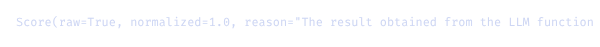

In [ ]:
judge_scoring = score_metric(trial=trial, metric=correctness_2)
judge_scoring.score

Finally, we can make a full run: execute our `detect_hate` target function on all the examples from our dataset and evaluate our two metrics on the outputs.

In [ ]:
from lmeh.execution import run_experiment
from lmeh.datatypes import Experiment

experiment = Experiment(
    name="silly-test",
    target=detect_hate,
    prompt_template=prompt_template,
    config=config,
)

results = run_experiment(
    experiment=experiment,
    dataset=dataset,
    metrics=[correctness, correctness_2],
    workers=5
)

And we can use a reporting utility to see the results.

In [ ]:
from lmeh.reporting import markdown_report
mo.md(markdown_report(results))

<span class="markdown prose dark:prose-invert contents"><h1 id="run-report-silly-test">Run report: <code>silly-test</code></h1>
<span class="paragraph">Summary of one experiment run across the dataset.</span>
<h2 id="experiment">Experiment</h2>
<ul>
<li><strong>Model</strong>: <code>mistral:mistral-small-latest</code></li>
<li><strong>Run timestamp</strong>: 2026-05-18T20:35:31.095447+00:00</li>
</ul>
<h2 id="quality">Quality</h2>
<span class="paragraph">Mean normalized score across every successful scoring (higher is better, in <code>[0, 1]</code>).</span>
<ul>
<li><strong>Mean normalized score</strong>: 0.8000</li>
</ul>
<h3 id="per-metric-mean-normalized-score">Per-metric mean normalized score</h3>
<table>
<thead>
<tr>
<th>Metric</th>
<th>Mean normalized</th>
</tr>
</thead>
<tbody>
<tr>
<td><code>correctness</code></td>
<td>0.8000</td>
</tr>
<tr>
<td><code>correctness2</code></td>
<td>0.8000</td>
</tr>
</tbody>
</table>
<h2 id="reliability">Reliability</h2>
<span class="paragraph">Trial failures count against the run (the target is under evaluation); scorer failures are excluded from quality aggregates.</span>
<ul>
<li><strong>Trials</strong>: 5 successful / 5 total</li>
<li><strong>Trial failure rate</strong>: 0.00%</li>
<li><strong>Scorings</strong>: 10 successful / 10 total</li>
<li><strong>Scoring failure rate</strong>: 0.00%</li>
</ul>
<h2 id="telemetry">Telemetry</h2>
<span class="paragraph">Averages across successful trials only.</span>
<ul>
<li><strong>Mean latency</strong>: 1.739 s</li>
<li><strong>Mean output tokens</strong>: 54.8</li>
<li><strong>Total output tokens</strong>: 274</li>
</ul></span>